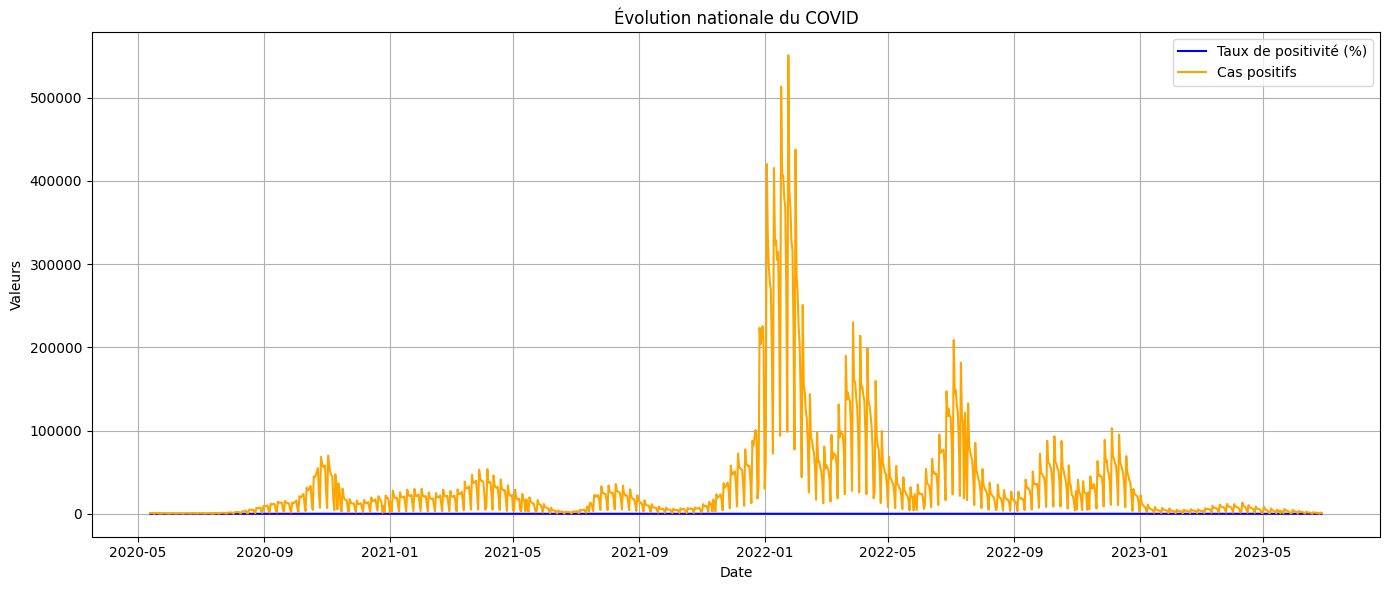

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_covid = pd.read_csv("/Users/ryangirard/PROJET-FIL-ROUGE/PROJET_FIL_ROUGE/data/COVID/sp-dep-jour-2023-06-30-16h26.csv", sep=";")

df_covid = df_covid.dropna(subset=["jour", "P", "T"])
df_covid["jour"] = pd.to_datetime(df_covid["jour"])

df_national = df_covid.groupby("jour").agg({
    "P": lambda x: pd.to_numeric(x.str.replace(",", "."), errors="coerce").sum(),
    "T": lambda x: pd.to_numeric(x.str.replace(",", "."), errors="coerce").sum()
}).reset_index()

df_national["Tp"] = (df_national["P"] / df_national["T"]) * 100

plt.figure(figsize=(14, 6))
plt.plot(df_national["jour"], df_national["Tp"], label="Taux de positivité (%)", color="blue")
plt.plot(df_national["jour"], df_national["P"], label="Cas positifs", color="orange")
plt.title("Évolution nationale du COVID")
plt.xlabel("Date")
plt.ylabel("Valeurs")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [36]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv("/Users/ryangirard/PROJET-FIL-ROUGE/PROJET_FIL_ROUGE/data/COVID/sp-dep-jour-cage10-2023-06-30-16h29.csv", sep=";", dtype=str)

for col in ["P", "T", "Tp", "Ti", "Td"]:
    df[col] = df[col].str.replace(",", ".").astype(float)

df["jour"] = pd.to_datetime(df["jour"], errors="coerce")

df["cl_age90"] = df["cl_age90"].astype(int)

df = df.dropna(subset=["jour", "P"])
df = df[df["P"] > 0]

age_map = {
    9: "0-9 ans", 19: "10-19 ans", 29: "20-29 ans",
    39: "30-39 ans", 49: "40-49 ans", 59: "50-59 ans",
    69: "60-69 ans", 79: "70-79 ans", 89: "80-89 ans", 90: "90+"
}
df["tranche"] = df["cl_age90"].map(age_map)

df_grouped = df.groupby(["jour", "tranche"])["P"].sum().reset_index()

fig = go.Figure()
buttons = []
tranches = df_grouped["tranche"].unique()

for i, tranche in enumerate(tranches):
    d = df_grouped[df_grouped["tranche"] == tranche]
    fig.add_trace(go.Scatter(
        x=d["jour"], y=d["P"], mode="lines", name=tranche,
        visible=(i == 0)
    ))

    vis = [False] * len(tranches)
    vis[i] = True
    buttons.append(dict(
        label=tranche,
        method="update",
        args=[{"visible": vis},
              {"title": f"Évolution des cas COVID - {tranche}"}]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.1, y=1.15,
        xanchor="left", yanchor="top"
    )],
    title="Évolution des cas COVID par tranche d’âge",
    xaxis_title="Date",
    yaxis_title="Nombre de cas positifs",
    height=600
)

fig.show()


In [71]:
import pandas as pd
import plotly.express as px
import requests
from dash import Dash, dcc, html, Input, Output

df = pd.read_csv("/Users/ryangirard/PROJET-FIL-ROUGE/PROJET_FIL_ROUGE/data/COVID/sp-dep-jour-2023-06-30-16h26.csv", sep=";", dtype=str)

df["jour"] = pd.to_datetime(df["jour"], errors="coerce")
df["P"] = df["P"].str.replace(",", ".").astype(float)
df = df.dropna(subset=["jour", "dep", "P"])
df["dep"] = df["dep"].astype(str).str.zfill(2)
df["jour_str"] = df["jour"].dt.strftime("%Y-%m-%d")

dates_dispo = sorted(df["jour_str"].unique())     # Les 30 derniers jours
df = df[df["jour_str"].isin(dates_dispo)]

geojson_url = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
geojson = requests.get(geojson_url).json()

app = Dash(__name__)
app.title = "Carte COVID Interactive"

app.layout = html.Div([
    html.H2("Carte COVID-19 par département", style={"textAlign": "center"}),

    html.Div([
        html.Label("📅 Sélectionnez une date :"),
        dcc.Dropdown(
            id="date-picker",
            options=[{"label": d, "value": d} for d in dates_dispo],
            value=dates_dispo[-1],  # dernière date par défaut
            clearable=False
        )
    ], style={"width": "40%", "margin": "auto"}),

    dcc.Graph(id="covid-map", style={"height": "700px", "marginTop": "20px"})
])

@app.callback(
    Output("covid-map", "figure"),
    Input("date-picker", "value")
)
def update_map(date_str):
    df_date = df[df["jour_str"] == date_str]

    fig = px.choropleth(
        df_date,
        geojson=geojson,
        locations="dep",
        featureidkey="properties.code",
        color="P",
        color_continuous_scale="Reds",
        range_color=(0, df["P"].max()),
        scope="europe",
        labels={"P": "Cas positifs"},
        hover_name="dep",
        title=f"Cas positifs COVID-19 par département - {date_str}"
    )

    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
    return fig

if __name__ == "__main__":
    app.run(debug=True)


Départements les plus touchés par le COVID-19 (cumul des cas positifs) :
dep
59    1578099.0
13    1422340.0
75    1355402.0
69    1232254.0
92     968663.0
33     942741.0
31     910302.0
93     846906.0
78     837364.0
62     837033.0
Name: P, dtype: float64


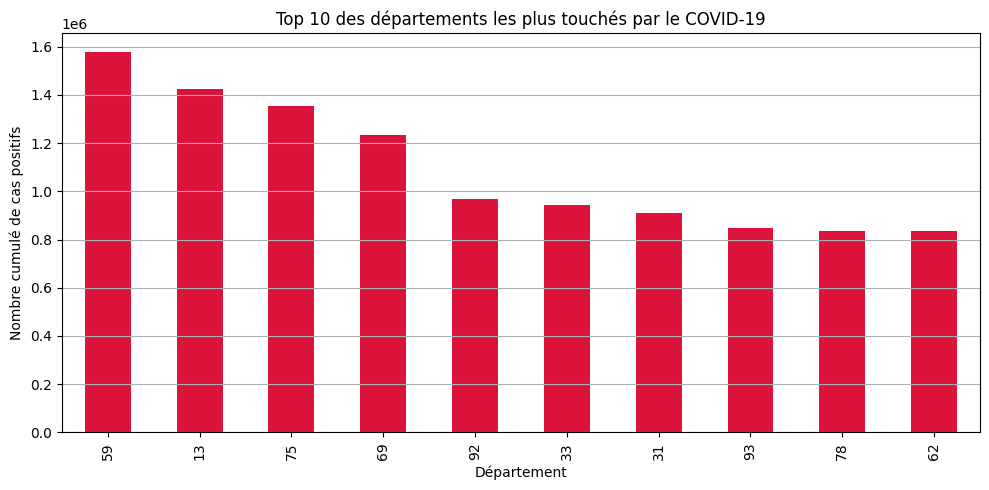

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ryangirard/PROJET-FIL-ROUGE/PROJET_FIL_ROUGE/data/COVID/sp-dep-jour-2023-06-30-16h26.csv", sep=";", dtype=str)

df = df[df["cl_age90"] == "0"]

df["P"] = pd.to_numeric(df["P"].str.replace(",", "."), errors="coerce")

cas_cumules_par_dep = df.groupby("dep")["P"].sum().sort_values(ascending=False)

print("Départements les plus touchés par le COVID-19 (cumul des cas positifs) :")
print(cas_cumules_par_dep.head(10))

cas_cumules_par_dep.head(10).plot(kind="bar", figsize=(10, 5), color="crimson")
plt.title("Top 10 des départements les plus touchés par le COVID-19")
plt.xlabel("Département")
plt.ylabel("Nombre cumulé de cas positifs")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


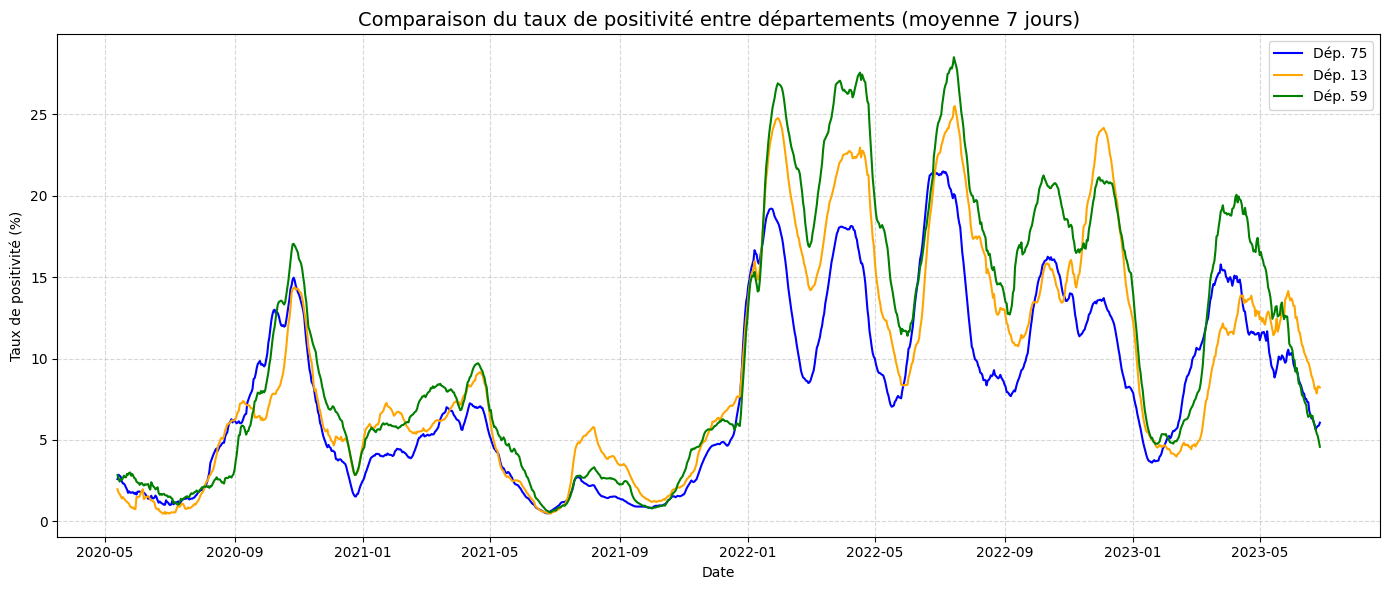

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

departements = ["75", "13", "59",  ]

df_sub = df_covid[df_covid["dep"].isin(departements)].copy()

df_sub["Tp"] = pd.to_numeric(df_sub["Tp"].astype(str).str.replace(",", "."), errors="coerce")

df_sub = df_sub.sort_values(["dep", "jour"])
df_sub["Tp_lissé"] = df_sub.groupby("dep")["Tp"].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

plt.figure(figsize=(14, 6))
colors = {"75": "blue", "13": "orange", "59": "green"}

for dep in departements:
    d = df_sub[df_sub["dep"] == dep]
    plt.plot(d["jour"], d["Tp_lissé"], label=f"Dép. {dep}", color=colors[dep])

plt.title("Comparaison du taux de positivité entre départements (moyenne 7 jours)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Taux de positivité (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

df_pib = pd.read_csv("/Users/ryangirard/PROJET-FIL-ROUGE/PROJET_FIL_ROUGE/data/PIB/CLVMNACSCAB1GQFR.csv")
df_pib = df_pib.rename(columns={"CLVMNACSCAB1GQFR": "PIB"})
df_pib["observation_date"] = pd.to_datetime(df_pib["observation_date"])
df_pib = df_pib[df_pib["observation_date"] >= "2017-01-01"]
df_pib["trimestre"] = df_pib["observation_date"].dt.to_period("Q").astype(str)
df_pib = df_pib[["trimestre", "PIB"]]

df_covid = pd.read_csv("/Users/ryangirard/PROJET-FIL-ROUGE/PROJET_FIL_ROUGE/data/COVID/sp-dep-jour-2023-06-30-16h26.csv", sep=";", dtype=str)
df_covid = df_covid[df_covid["cl_age90"] == "0"]
df_covid["jour"] = pd.to_datetime(df_covid["jour"])
df_covid["P"] = pd.to_numeric(df_covid["P"].str.replace(",", "."), errors="coerce")
df_covid["trimestre"] = df_covid["jour"].dt.to_period("Q").astype(str)
df_covid_trim = df_covid.groupby("trimestre")["P"].sum().reset_index().rename(columns={"P": "Cas_COVID"})

df_merge = pd.merge(df_pib, df_covid_trim, on="trimestre", how="left")
df_merge["Cas_COVID"] = df_merge["Cas_COVID"].fillna(0)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_merge["trimestre"],
    y=df_merge["Cas_COVID"],
    name="Cas COVID",
    mode="lines+markers",
    yaxis="y1",
    line=dict(color="crimson")
))
fig.add_trace(go.Scatter(
    x=df_merge["trimestre"],
    y=df_merge["PIB"],
    name="PIB (en M€)",
    mode="lines+markers",
    yaxis="y2",
    line=dict(color="royalblue")
))
fig.update_layout(
    title="📉 Évolution du PIB depuis 2017 et impact du COVID à partir de 2020",
    xaxis=dict(title="Trimestre"),
    yaxis=dict(title="Nombre de cas COVID", color="crimson", tickfont=dict(color="crimson")),
    yaxis2=dict(title="PIB (en millions €)", overlaying="y", side="right", tickfont=dict(color="royalblue")),
    legend=dict(x=0.05, y=1.1, orientation="h"),
    height=600,
    margin=dict(t=80)
)
fig.show()
